# Practical Statistics for Data Scientists (Python)
# Chapter 4. Regression and Prediction
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck

## Loading the rpy2 extension in a notebook with the Python kernel

In [1]:
import sys
import io

stderr_original = sys.stderr
sys.stderr = io.StringIO()

# Loading the extension without noise
%load_ext rpy2.ipython

sys.stderr = stderr_original  # Restore silently

In [2]:
%%R
suppressWarnings(
  invisible(
    try(Sys.setlocale("LC_ALL", "English"), silent = TRUE)
  )
)

## Import packages

### Import required Python packages

In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence

from pygam import LinearGAM, s, l
from pygam.datasets import wage


import seaborn as sns
import matplotlib.pyplot as plt

from dmba import stepwise_selection
from dmba import AIC_score

In [4]:
%matplotlib inline

In [5]:
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

### Import required R packages

In [6]:
%%R
library(MASS)
library(dplyr)
library(tidyr)
library(ggplot2)
library(lubridate)
library(splines)
library(mgcv)


Dolaczanie pakietu: 'dplyr'

Nastepujacy obiekt zostal zakryty z 'package:MASS':

    select

Nastepujace obiekty zostaly zakryte z 'package:stats':

    filter, lag

Nastepujace obiekty zostaly zakryte z 'package:base':

    intersect, setdiff, setequal, union


Dolaczanie pakietu: 'lubridate'

Nastepujace obiekty zostaly zakryte z 'package:base':

    date, intersect, setdiff, union

Ladowanie wymaganego pakietu: nlme

Dolaczanie pakietu: 'nlme'

Nastepujacy obiekt zostal zakryty z 'package:dplyr':

    collapse

This is mgcv 1.9-1. For overview type 'help("mgcv-package")'.


## Defining data paths
If you don't keep your data in the same directory as the code, adapt the path names.

### Python

In [7]:
LUNG_CSV = DATA / 'LungDisease.csv'
HOUSE_CSV = DATA / 'house_sales.csv'

### R

In [8]:
%%R
PSDS_PATH <- file.path(dirname(dirname(getwd())))


lung <- read.csv(file.path(PSDS_PATH, 'data', 'LungDisease.csv'))
house <- read.csv(file.path(PSDS_PATH, 'data', 'house_sales.csv'), sep='\t')

# Simple Linear Regression
## The Regression Equation

### Python

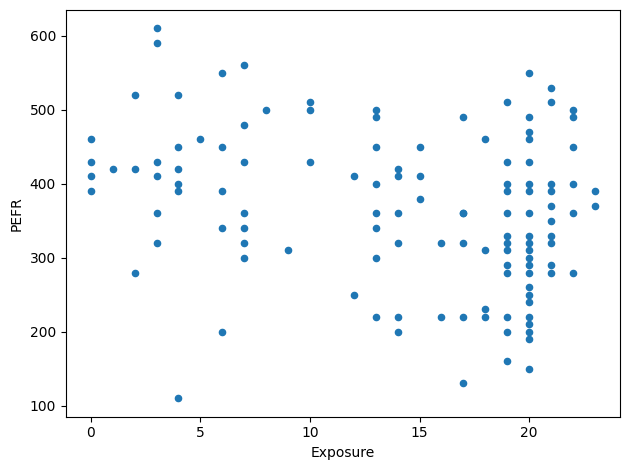

In [9]:
lung = pd.read_csv(LUNG_CSV)

lung.plot.scatter(x='Exposure', y='PEFR')

plt.tight_layout()
plt.show()

We can use the `LinearRegression` model from _scikit-learn_.

In [10]:
predictors = ['Exposure']
outcome = 'PEFR'

model = LinearRegression()
model.fit(lung[predictors], lung[outcome])

print(f'Intercept: {model.intercept_:.3f}')
print(f'Coefficient Exposure: {model.coef_[0]:.3f}')

Intercept: 424.583
Coefficient Exposure: -4.185


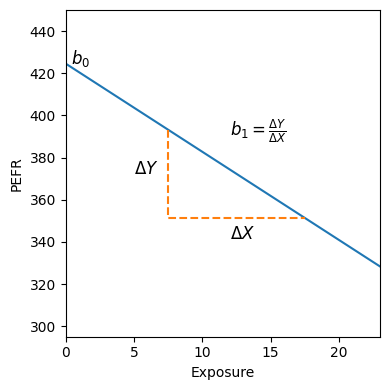

In [11]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(0, 23)
ax.set_ylim(295, 450)
ax.set_xlabel('Exposure')
ax.set_ylabel('PEFR')
ax.plot((0, 23), model.predict(pd.DataFrame({'Exposure': [0, 23]})))
ax.text(0.4, model.intercept_, r'$b_0$', size='larger')

x = pd.DataFrame({'Exposure': [7.5,17.5]})
y = model.predict(x)
ax.plot((7.5, 7.5, 17.5), (y[0], y[1], y[1]), '--')
ax.text(5, np.mean(y), r'$\Delta Y$', size='larger')
ax.text(12, y[1] - 10, r'$\Delta X$', size='larger')
ax.text(12, 390, r'$b_1 = \frac{\Delta Y}{\Delta X}$', size='larger')

plt.tight_layout()
plt.show()

### R

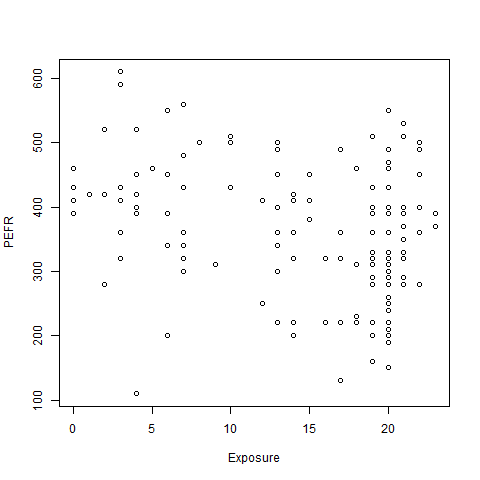

In [12]:
%%R
plot(lung$Exposure, lung$PEFR, xlab="Exposure", ylab="PEFR")

In [13]:
%%R
model <- lm(PEFR ~ Exposure, data=lung)
model


Call:
lm(formula = PEFR ~ Exposure, data = lung)

Coefficients:
(Intercept)     Exposure  
    424.583       -4.185  



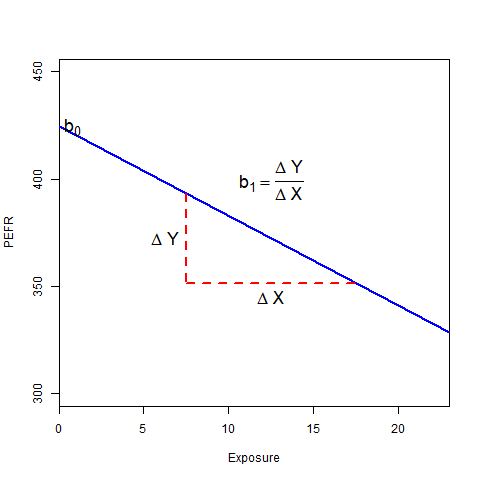

In [14]:
%%R
plot(lung$Exposure, lung$PEFR, xlab="Exposure", ylab="PEFR", ylim=c(300,450), type="n", xaxs="i")
abline(a=model$coefficients[1], b=model$coefficients[2], col="blue", lwd=2)
text(x=.3, y=model$coefficients[1], labels=expression("b"[0]),  adj=0, cex=1.5)
x <- c(7.5, 17.5)
y <- predict(model, newdata=data.frame(Exposure=x))
segments(x[1], y[2], x[2], y[2] , col="red", lwd=2, lty=2)
segments(x[1], y[1], x[1], y[2] , col="red", lwd=2, lty=2)
text(x[1], mean(y), labels=expression(Delta~Y), pos=2, cex=1.5)
text(mean(x), y[2], labels=expression(Delta~X), pos=1, cex=1.5)
text(mean(x), 400, labels=expression(b[1] == frac(Delta ~ Y, Delta ~ X)), cex=1.5)

## Fitted Values and Residuals

### Python
The method `predict` of a fitted _scikit-learn_ model can be used to predict new data points.

In [15]:
fitted = model.predict(lung[predictors])
residuals = lung[outcome] - fitted

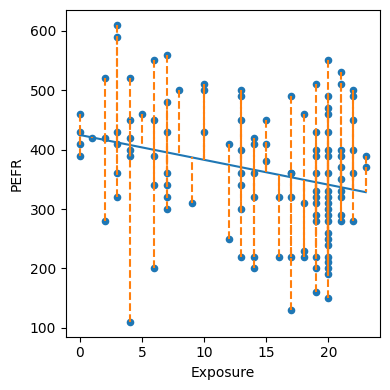

In [16]:
ax = lung.plot.scatter(x='Exposure', y='PEFR', figsize=(4, 4))
ax.plot(lung.Exposure, fitted)
for x, yactual, yfitted in zip(lung.Exposure, lung.PEFR, fitted): 
    ax.plot((x, x), (yactual, yfitted), '--', color='C1')

plt.tight_layout()
plt.show()

### R

In [17]:
%%R
fitted <- predict(model)
resid <- residuals(model)

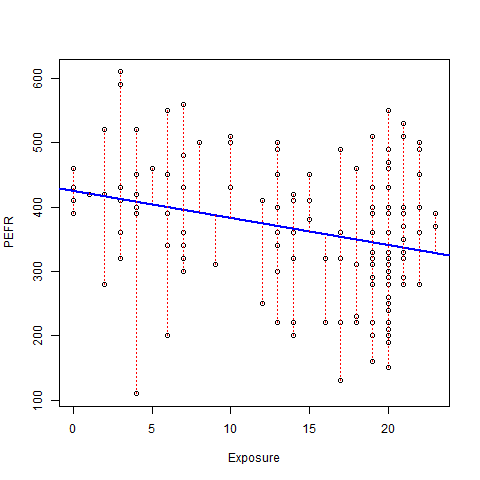

In [18]:
%%R
lung1 <- lung %>%
  mutate(Fitted=fitted,
         positive = PEFR>Fitted) %>%
  group_by(Exposure, positive) %>%
  summarize(PEFR_max = max(PEFR), 
            PEFR_min = min(PEFR),
            Fitted = first(Fitted), 
            .groups='keep') %>%
  ungroup() %>%
  mutate(PEFR = ifelse(positive, PEFR_max, PEFR_min)) %>%
  arrange(Exposure)

plot(lung$Exposure, lung$PEFR, xlab="Exposure", ylab="PEFR")
abline(a=model$coefficients[1], b=model$coefficients[2], col="blue", lwd=2)
segments(lung1$Exposure, lung1$PEFR, lung1$Exposure, lung1$Fitted, col="red", lty=3)

# Multiple linear regression

### Python

In [19]:
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
          'Bedrooms', 'BldgGrade']

house = pd.read_csv(HOUSE_CSV, sep='\t')
print(house[subset].head())

   AdjSalePrice  SqFtTotLiving  SqFtLot  Bathrooms  Bedrooms  BldgGrade
1      300805.0           2400     9373       3.00         6          7
2     1076162.0           3764    20156       3.75         4         10
3      761805.0           2060    26036       1.75         4          8
4      442065.0           3200     8618       3.75         5          7
5      297065.0           1720     8620       1.75         4          7


In [20]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])

print(f'Intercept: {house_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(predictors, house_lm.coef_):
    print(f' {name}: {coef}')

Intercept: -521871.368
Coefficients:
 SqFtTotLiving: 228.83060360240793
 SqFtLot: -0.06046682065307607
 Bathrooms: -19442.840398321066
 Bedrooms: -47769.95518521438
 BldgGrade: 106106.96307898081


### R

In [21]:
%%R
print(head(house[, c('AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
               'Bedrooms', 'BldgGrade')]))

  AdjSalePrice SqFtTotLiving SqFtLot Bathrooms Bedrooms BldgGrade
       300805          2400    9373      3.00        6         7
      1076162          3764   20156      3.75        4        10
       761805          2060   26036      1.75        4         8
       442065          3200    8618      3.75        5         7
       297065          1720    8620      1.75        4         7
       411781           930    1012      1.50        2         8


In [22]:
%%R
house_lm <- lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
                 Bedrooms + BldgGrade,  
               data=house, na.action=na.omit)

house_lm


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
    Bedrooms + BldgGrade, data = house, na.action = na.omit)

Coefficients:
  (Intercept)  SqFtTotLiving        SqFtLot      Bathrooms       Bedrooms  
   -5.219e+05      2.288e+02     -6.047e-02     -1.944e+04     -4.777e+04  
    BldgGrade  
    1.061e+05  



## Assessing the Model

### Python
_Scikit-learn_ provides a number of metrics to determine the quality of a model. Here we use the `r2_score`.

In [23]:
fitted = house_lm.predict(house[predictors])
RMSE = np.sqrt(mean_squared_error(house[outcome], fitted))
r2 = r2_score(house[outcome], fitted)
print(f'RMSE: {RMSE:.0f}')
print(f'r2: {r2:.4f}')

RMSE: 261220
r2: 0.5406


While _scikit-learn_ provides a variety of different metrics, _statsmodels_ provides a more in-depth analysis of the linear regression model. This package has two different ways of specifying the model, one that is similar to _scikit-learn_ and one that allows specifying _R_-style formulas. Here we use the first approach. As _statsmodels_ doesn't add an intercept automaticaly, we need to add a constant column with value 1 to the predictors. We can use the _pandas_ method assign for this.

In [24]:
model = sm.OLS(house[outcome], house[predictors].assign(const=1))
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Wed, 26 Nov 2025   Prob (F-statistic):               0.00
Time:                        19:01:56   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   228.8306      3.899     58.694

### R

In [25]:
%%R
summary(house_lm)


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
    Bedrooms + BldgGrade, data = house, na.action = na.omit)

Residuals:
     Min       1Q   Median       3Q      Max 
-1199479  -118908   -20977    87435  9473035 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
 -5.219e+05  1.565e+04 -33.342  < 2e-16 ***
  2.288e+02  3.899e+00  58.694  < 2e-16 ***
 -6.047e-02  6.118e-02  -0.988    0.323    
 -1.944e+04  3.625e+03  -5.363 8.27e-08 ***
 -4.777e+04  2.490e+03 -19.187  < 2e-16 ***
  1.061e+05  2.396e+03  44.277  < 2e-16 ***
---
0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

 261300 on 22681 degrees of freedom
Multiple R-squared:  0.5406,	Adjusted R-squared:  0.5405 
  5338 on 5 and 22681 DF,  p-value: < 2.2e-16



## Model Selection and Stepwise Regression

### Python

In [26]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'NbrLivingUnits',
              'SqFtFinBasement', 'YrBuilt', 'YrRenovated', 
              'NewConstruction']

X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)
X['NewConstruction'] = [1 if nc else 0 for nc in X['NewConstruction']]

house_full = sm.OLS(house[outcome], X.assign(const=1))
results = house_full.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     2771.
Date:                Wed, 26 Nov 2025   Prob (F-statistic):               0.00
Time:                        19:01:57   Log-Likelihood:            -3.1375e+05
No. Observations:               22687   AIC:                         6.275e+05
Df Residuals:                   22674   BIC:                         6.276e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
SqFtTotLiving       

We can use the `stepwise_selection` method from the _dmba_ package.

In [27]:
y = house[outcome]

def train_model(variables):
    if len(variables) == 0:
        return None
    model = LinearRegression()
    model.fit(X[variables], y)
    return model

def score_model(model, variables):
    if len(variables) == 0:
        return AIC_score(y, [y.mean()] * len(y), model, df=1)
    return AIC_score(y, model.predict(X[variables]), model)

best_model, best_variables = stepwise_selection(X.columns, train_model, score_model, 
                                                verbose=True)

print()
print(f'Intercept: {best_model.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(best_variables, best_model.coef_):
    print(f' {name}: {coef}')

Variables: SqFtTotLiving, SqFtLot, Bathrooms, Bedrooms, BldgGrade, NbrLivingUnits, SqFtFinBasement, YrBuilt, YrRenovated, NewConstruction, PropertyType_Single Family, PropertyType_Townhouse
Start: score=647988.32, constant
Step: score=633013.35, add SqFtTotLiving
Step: score=630793.74, add BldgGrade
Step: score=628230.29, add YrBuilt
Step: score=627784.16, add Bedrooms
Step: score=627602.21, add Bathrooms
Step: score=627525.65, add PropertyType_Townhouse
Step: score=627525.08, add SqFtFinBasement
Step: score=627524.98, add PropertyType_Single Family
Step: score=627524.98, unchanged None

Intercept: 6178645.017
Coefficients:
 SqFtTotLiving: 199.2775530420188
 BldgGrade: 137159.56022619782
 YrBuilt: -3565.4249392492984
 Bedrooms: -51947.38367361323
 Bathrooms: 42396.16452771774
 PropertyType_Townhouse: 84479.16203300416
 SqFtFinBasement: 7.046974967553979
 PropertyType_Single Family: 22912.055187017646


### R

In [28]:
%%R
house_full <- lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
                   Bedrooms + BldgGrade + PropertyType + NbrLivingUnits + 
                   SqFtFinBasement + YrBuilt + YrRenovated + NewConstruction,
                 data=house, na.action=na.omit)

## Code snippet 4.8
step_lm <- stepAIC(house_full, direction="both")
step_lm

Start:  AIC=563145.4
AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + Bedrooms + 
    BldgGrade + PropertyType + NbrLivingUnits + SqFtFinBasement + 
    YrBuilt + YrRenovated + NewConstruction

                  Df  Sum of Sq        RSS    AIC
  1 6.4007e+09 1.3662e+15 563144
  1 1.0592e+10 1.3662e+15 563144
  1 2.5069e+10 1.3662e+15 563144
  1 1.0657e+11 1.3663e+15 563145
               1.3662e+15 563145
  1 1.4030e+11 1.3663e+15 563146
  2 4.4207e+12 1.3706e+15 563215
  1 7.6325e+12 1.3738e+15 563270
  1 2.8212e+13 1.3944e+15 563607
  1 1.2906e+14 1.4952e+15 565191
  1 1.3264e+14 1.4988e+15 565246
  1 1.9050e+14 1.5567e+15 566105

563143.6IC=
AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + Bedrooms + 
    BldgGrade + PropertyType + SqFtFinBasement + YrBuilt + YrRenovated + 
    NewConstruction

                  Df  Sum of Sq        RSS    AIC
  1 1.0801e+10 1.3662e+15 563142
  1 2.5628e+10 1.3662e+15 563142
  1 1.0731e+11 1.3663e+15 563143
               1.3662e+15 563144
 

In [29]:
%%R
lm(AdjSalePrice ~  Bedrooms, data=house)


Call:
lm(formula = AdjSalePrice ~ Bedrooms, data = house)

Coefficients:
(Intercept)     Bedrooms  
     117354       132991  



## Weighted regression

### Python
We can calculate the Year from the date column using either a list comprehension or the data frame's `apply` method.

In [30]:
house['Year'] = [int(date.split('-')[0]) for date in house.DocumentDate]
house['Year'] = house.DocumentDate.apply(lambda d: int(d.split('-')[0]))
house['Weight'] = house.Year - 2005

In [31]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_wt = LinearRegression()
house_wt.fit(house[predictors], house[outcome], sample_weight=house.Weight)
 
pd.concat([
    pd.DataFrame({
        'predictor': predictors,
        'house_lm': house_lm.coef_,
        'house_wt': house_wt.coef_,    
    }),
    pd.DataFrame({
        'predictor': ['intercept'],
        'house_lm': house_lm.intercept_,
        'house_wt': house_wt.intercept_,    
    })
])

,predictor,house_lm,house_wt
0,SqFtTotLiving,228.830604,245.024089
1,SqFtLot,-0.060467,-0.292415
2,Bathrooms,-19442.840398,-26085.970109
3,Bedrooms,-47769.955185,-53608.876436
4,BldgGrade,106106.963079,115242.434726
0,intercept,-521871.368188,-584189.329446


In [32]:
residuals = pd.DataFrame({
    'abs_residual_lm': np.abs(house_lm.predict(house[predictors]) - house[outcome]),
    'abs_residual_wt': np.abs(house_wt.predict(house[predictors]) - house[outcome]),
    'Year': house['Year'],
})
print(residuals.head())
# axes = residuals.boxplot(['abs_residual_lm', 'abs_residual_wt'], by='Year', figsize=(10, 4))
# axes[0].set_ylim(0, 300000)

pd.DataFrame(([year, np.mean(group['abs_residual_lm']), np.mean(group['abs_residual_wt'])] 
              for year, group in residuals.groupby('Year')),
             columns=['Year', 'mean abs_residual_lm', 'mean abs_residual_wt'])
# for year, group in residuals.groupby('Year'):
#     print(year, np.mean(group['abs_residual_lm']), np.mean(group['abs_residual_wt']))

   abs_residual_lm  abs_residual_wt  Year
1    123750.814194    107108.553965  2014
2     59145.413089     96191.882094  2006
3    190108.725716    187004.492880  2007
4    198788.774412    196132.996857  2008
5     91774.996129     84277.577512  2013


,Year,mean abs_residual_lm,mean abs_residual_wt
0,2006,140540.303585,146557.454636
1,2007,147747.577959,152848.523235
2,2008,142086.905943,146360.411668
3,2009,147016.720883,151182.924825
4,2010,163267.674885,166364.476152
5,2011,169937.385744,172950.876028
6,2012,169506.670053,171874.424266
7,2013,203659.777510,206242.199403
8,2014,184452.840665,186668.573750
9,2015,172323.435147,169842.742053


### R

In [33]:
%%R
house$Year = year(house$DocumentDate)
house$Weight = house$Year - 2005

house_wt <- lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
                 Bedrooms + BldgGrade,
               data=house, weight=Weight, na.action=na.omit)
round(cbind(house_lm=house_lm$coefficients, 
            house_wt=house_wt$coefficients), digits=3)

                 house_lm    house_wt
 -521871.368 -584189.329
     228.831     245.024
      -0.060      -0.292
  -19442.840  -26085.970
  -47769.955  -53608.876
  106106.963  115242.435


# Factor variables in regression
## Dummy Variables Representation

### Python

In [34]:
print(house.PropertyType.head())

1        Multiplex
2    Single Family
3    Single Family
4    Single Family
5    Single Family
Name: PropertyType, dtype: object


In [35]:
print(pd.get_dummies(house['PropertyType']).head(6))

   Multiplex  Single Family  Townhouse
1       True          False      False
2      False           True      False
3      False           True      False
4      False           True      False
5      False           True      False
6      False          False       True


In [36]:
print(pd.get_dummies(house['PropertyType'], drop_first=True).head(6))

   Single Family  Townhouse
1          False      False
2           True      False
3           True      False
4           True      False
5           True      False
6          False       True


In [37]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType']

X = pd.get_dummies(house[predictors], drop_first=True)

house_lm_factor = LinearRegression()
house_lm_factor.fit(X, house[outcome])

print(f'Intercept: {house_lm_factor.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, house_lm_factor.coef_):
    print(f' {name}: {coef}')

Intercept: -446841.366
Coefficients:
 SqFtTotLiving: 223.37362892503828
 SqFtLot: -0.07036798136813083
 Bathrooms: -15979.013473415205
 Bedrooms: -50889.73218483025
 BldgGrade: 109416.30516146179
 PropertyType_Single Family: -84678.21629549257
 PropertyType_Townhouse: -115121.97921609184


### R

In [38]:
%%R
head(house[, 'PropertyType'])

[1] "Multiplex"     "Single Family" "Single Family" "Single Family"
[5] "Single Family" "Townhouse"    


In [39]:
%%R
prop_type_dummies <- model.matrix(~PropertyType -1, data=house)
head(prop_type_dummies)

  PropertyTypeMultiplex PropertyTypeSingle Family PropertyTypeTownhouse
                     1                         0                     0
                     0                         1                     0
                     0                         1                     0
                     0                         1                     0
                     0                         1                     0
                     0                         0                     1


In [40]:
%%R
lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
     Bedrooms +  BldgGrade + PropertyType, data=house)


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
    Bedrooms + BldgGrade + PropertyType, data = house)

Coefficients:
              (Intercept)              SqFtTotLiving  
               -4.468e+05                  2.234e+02  
                  SqFtLot                  Bathrooms  
               -7.037e-02                 -1.598e+04  
                 Bedrooms                  BldgGrade  
               -5.089e+04                  1.094e+05  
PropertyTypeSingle Family      PropertyTypeTownhouse  
               -8.468e+04                 -1.151e+05  



## Factor Variables with many levels

### Python

In [41]:
print(pd.DataFrame(house['ZipCode'].value_counts()).transpose())

ZipCode  98038  98103  98042  98115  98117  98052  98034  98033  98059  98074  \
count      788    671    641    620    619    614    575    517    513    502   

ZipCode  ...  98051  98024  98354  98050  98057  98288  98224  98068  98113  \
count    ...     32     31      9      7      4      4      3      1      1   

ZipCode  98043  
count        1  

[1 rows x 80 columns]


In [42]:
house = pd.read_csv(HOUSE_CSV, sep='\t')

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])


zip_residuals = pd.DataFrame({
    'ZipCode': house['ZipCode'],
    'residual' : house[outcome] - house_lm.predict(house[predictors]),
})

zip_groups = pd.DataFrame([
    {
        'ZipCode': zipCode,
        'count': len(x),
        'median_residual': x.residual.median()
    } 
    for zipCode, x in zip_residuals.groupby('ZipCode')
]).sort_values('median_residual')

zip_groups['cum_count'] = np.cumsum(zip_groups['count'])
zip_groups['ZipGroup'] = pd.qcut(zip_groups['cum_count'], 5, labels=False, retbins=False)
zip_groups.head()
print(zip_groups.ZipGroup.value_counts().sort_index())

ZipGroup
0    16
1    16
2    16
3    16
4    16
Name: count, dtype: int64


In [43]:
to_join = zip_groups[['ZipCode', 'ZipGroup']].set_index('ZipCode')
house = house.join(to_join, on='ZipCode')
house['ZipGroup'] = house['ZipGroup'].astype('category')

### R

In [44]:
%%R
table(house$ZipCode)


98001 98002 98003 98004 98005 98006 98007 98008 98010 98011 98014 98019 98022 
  358   180   241   293   133   460   112   291    56   163    85   242   188 
98023 98024 98027 98028 98029 98030 98031 98032 98033 98034 98038 98039 98040 
  455    31   366   252   475   263   308   121   517   575   788    47   244 
98042 98043 98045 98047 98050 98051 98052 98053 98055 98056 98057 98058 98059 
  641     1   222    48     7    32   614   499   332   402     4   420   513 
98065 98068 98070 98072 98074 98075 98077 98092 98102 98103 98105 98106 98107 
  430     1    89   245   502   388   204   289   106   671   313   361   296 
98108 98109 98112 98113 98115 98116 98117 98118 98119 98122 98125 98126 98133 
  155   149   357     1   620   364   619   492   260   380   409   473   465 
98136 98144 98146 98148 98155 98166 98168 98177 98178 98188 98198 98199 98224 
  310   332   287    40   358   193   332   216   266   101   225   393     3 
98288 98354 
    4     9 


In [45]:
%%R
zip_groups <- house %>%
  mutate(resid = residuals(house_lm)) %>%
  group_by(ZipCode) %>%
  summarize(med_resid = median(resid),
            cnt = n()) %>%
  # sort the zip codes by the median residual
  arrange(med_resid) %>%
  mutate(cum_cnt = cumsum(cnt),
         ZipGroup = factor(ntile(cum_cnt, 5)))
house <- house %>%
  left_join(dplyr::select(zip_groups, ZipCode, ZipGroup), by='ZipCode')

In [46]:
%%R
table(zip_groups[c('ZipGroup')])

ZipGroup
 1  2  3  4  5 
16 16 16 16 16 


# Interpreting the Regression Equation
## Correlated predictors

### Python

The results from the stepwise regression are.

In [47]:
print(f'Intercept: {best_model.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(best_variables, best_model.coef_):
    print(f' {name}: {coef}')

Intercept: 6178645.017
Coefficients:
 SqFtTotLiving: 199.2775530420188
 BldgGrade: 137159.56022619782
 YrBuilt: -3565.4249392492984
 Bedrooms: -51947.38367361323
 Bathrooms: 42396.16452771774
 PropertyType_Townhouse: 84479.16203300416
 SqFtFinBasement: 7.046974967553979
 PropertyType_Single Family: 22912.055187017646


In [48]:
predictors = ['Bedrooms', 'BldgGrade', 'PropertyType', 'YrBuilt']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True)

reduced_lm = LinearRegression()
reduced_lm.fit(X, house[outcome])


print(f'Intercept: {reduced_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, reduced_lm.coef_):
    print(f' {name}: {coef}')

Intercept: 4913973.344
Coefficients:
 Bedrooms: 27150.537230215377
 BldgGrade: 248997.79366213758
 YrBuilt: -3211.7448621550866
 PropertyType_Single Family: -19898.495340502435
 PropertyType_Townhouse: -47355.4368733449


### R

The results from the stepwise regression are.

In [49]:
%%R
step_lm$coefficients

              (Intercept)             SqFtTotLiving                 Bathrooms 
             6.178645e+06              1.992776e+02              4.239616e+04 
                 Bedrooms                 BldgGrade PropertyTypeSingle Family 
            -5.194738e+04              1.371596e+05              2.291206e+04 
    PropertyTypeTownhouse           SqFtFinBasement                   YrBuilt 
             8.447916e+04              7.046975e+00             -3.565425e+03 


In [50]:
%%R
update(step_lm, . ~ . -SqFtTotLiving - SqFtFinBasement - Bathrooms)


Call:
lm(formula = AdjSalePrice ~ Bedrooms + BldgGrade + PropertyType + 
    YrBuilt, data = house, na.action = na.omit)

Coefficients:
              (Intercept)                   Bedrooms  
                  4913973                      27151  
                BldgGrade  PropertyTypeSingle Family  
                   248998                     -19898  
    PropertyTypeTownhouse                    YrBuilt  
                   -47355                      -3212  



## Confounding variables

### Python

In [51]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'ZipGroup']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True)

confounding_lm = LinearRegression()
confounding_lm.fit(X, house[outcome])

print(f'Intercept: {confounding_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, confounding_lm.coef_):
    print(f' {name}: {coef}')

Intercept: -666637.469
Coefficients:
 SqFtTotLiving: 210.61266005580154
 SqFtLot: 0.45498713854658845
 Bathrooms: 5928.42564000163
 Bedrooms: -41682.87184074476
 BldgGrade: 98541.18352725972
 PropertyType_Single Family: 19323.6252879192
 PropertyType_Townhouse: -78198.720927624
 ZipGroup_1: 53317.17330659817
 ZipGroup_2: 116251.58883563551
 ZipGroup_3: 178360.53178793378
 ZipGroup_4: 338408.60185652034


### R

In [52]:
%%R
lm(AdjSalePrice ~  SqFtTotLiving + SqFtLot + 
     Bathrooms + Bedrooms + 
     BldgGrade + PropertyType + ZipGroup,
   data=house, na.action=na.omit)


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
    Bedrooms + BldgGrade + PropertyType + ZipGroup, data = house, 
    na.action = na.omit)

Coefficients:
              (Intercept)              SqFtTotLiving  
               -6.666e+05                  2.106e+02  
                  SqFtLot                  Bathrooms  
                4.550e-01                  5.928e+03  
                 Bedrooms                  BldgGrade  
               -4.168e+04                  9.854e+04  
PropertyTypeSingle Family      PropertyTypeTownhouse  
                1.932e+04                 -7.820e+04  
                ZipGroup2                  ZipGroup3  
                5.332e+04                  1.163e+05  
                ZipGroup4                  ZipGroup5  
                1.784e+05                  3.384e+05  



## Interactions and Main Effects

### Python

In [53]:
model = smf.ols(formula='AdjSalePrice ~  SqFtTotLiving*ZipGroup + SqFtLot + ' +
     'Bathrooms + Bedrooms + BldgGrade + PropertyType', data=house)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     3247.
Date:                Wed, 26 Nov 2025   Prob (F-statistic):               0.00
Time:                        19:02:01   Log-Likelihood:            -3.1098e+05
No. Observations:               22687   AIC:                         6.220e+05
Df Residuals:                   22671   BIC:                         6.221e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

> Results differ from R due to different binning. Enforcing the same binning gives identical results

### R

In [54]:
%%R
lm(AdjSalePrice ~  SqFtTotLiving*ZipGroup + SqFtLot + 
     Bathrooms + Bedrooms + 
     BldgGrade + PropertyType,
   data=house, na.action=na.omit)


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving * ZipGroup + SqFtLot + 
    Bathrooms + Bedrooms + BldgGrade + PropertyType, data = house, 
    na.action = na.omit)

Coefficients:
              (Intercept)              SqFtTotLiving  
               -4.853e+05                  1.148e+02  
                ZipGroup2                  ZipGroup3  
               -1.113e+04                  2.032e+04  
                ZipGroup4                  ZipGroup5  
                2.050e+04                 -1.499e+05  
                  SqFtLot                  Bathrooms  
                6.869e-01                 -3.619e+03  
                 Bedrooms                  BldgGrade  
               -4.180e+04                  1.047e+05  
PropertyTypeSingle Family      PropertyTypeTownhouse  
                1.357e+04                 -5.884e+04  
  SqFtTotLiving:ZipGroup2    SqFtTotLiving:ZipGroup3  
                3.260e+01                  4.178e+01  
  SqFtTotLiving:ZipGroup4    SqFtTotLiving:ZipGro

# Testing the Assumptions: Regression Diagnostics
## Outliers

### Python

The _statsmodels_ package has the most developed support for outlier analysis. 

In [55]:
house_98105 = house.loc[house['ZipCode'] == 98105, ]

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade']
outcome = 'AdjSalePrice'

house_outlier = sm.OLS(house_98105[outcome], house_98105[predictors].assign(const=1))
result_98105 = house_outlier.fit()
print(result_98105.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     238.7
Date:                Wed, 26 Nov 2025   Prob (F-statistic):          1.69e-103
Time:                        19:02:01   Log-Likelihood:                -4226.0
No. Observations:                 313   AIC:                             8464.
Df Residuals:                     307   BIC:                             8486.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   209.6023     24.408      8.587

The `OLSInfluence` class is initialized with the OLS regression results and gives access to a number of usefule properties. Here we use the studentized residuals. 

In [56]:
influence = OLSInfluence(result_98105)
sresiduals = influence.resid_studentized_internal

print(sresiduals.idxmin(), sresiduals.min())

24333 -4.32673180407856


In [57]:
print(result_98105.resid.loc[sresiduals.idxmin()])

-757753.6192115822


In [58]:
outlier = house_98105.loc[sresiduals.idxmin(), :]
print('AdjSalePrice', outlier[outcome])
print(outlier[predictors])

AdjSalePrice 119748.0
SqFtTotLiving    2900
SqFtLot          7276
Bathrooms         3.0
Bedrooms            6
BldgGrade           7
Name: 24333, dtype: object


### R

In [59]:
%%R
house_98105 <- house[house$ZipCode == 98105,]
lm_98105 <- lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
                 Bedrooms + BldgGrade, data=house_98105)

In [60]:
%%R
summary(lm_98105)


Call:
lm(formula = AdjSalePrice ~ SqFtTotLiving + SqFtLot + Bathrooms + 
    Bedrooms + BldgGrade, data = house_98105)

Residuals:
    Min      1Q  Median      3Q     Max 
-757754  -91807   -9668   77586  953911 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
 -772549.86   98277.27  -7.861 6.51e-14 ***
     209.60      24.41   8.587 4.54e-16 ***
      38.93       5.33   7.305 2.41e-12 ***
    2282.26   19983.57   0.114   0.9091    
  -26320.27   12881.09  -2.043   0.0419 *  
  130000.10   15234.12   8.533 6.63e-16 ***
---
0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

 178500 on 307 degrees of freedom
Multiple R-squared:  0.7954,	Adjusted R-squared:  0.7921 
 238.7 on 5 and 307 DF,  p-value: < 2.2e-16



In [61]:
%%R
sresid <- rstandard(lm_98105)
idx <- order(sresid, decreasing=FALSE)
sresid[idx[1]]
resid(lm_98105)[idx[1]]

    20429 
-757753.6 


In [62]:
%%R
house_98105[idx[1], c('AdjSalePrice', 'SqFtTotLiving', 'SqFtLot',
                      'Bathrooms', 'Bedrooms', 'BldgGrade')]

      AdjSalePrice SqFtTotLiving SqFtLot Bathrooms Bedrooms BldgGrade
       119748          2900    7276         3        6         7


## Influential values

### Python

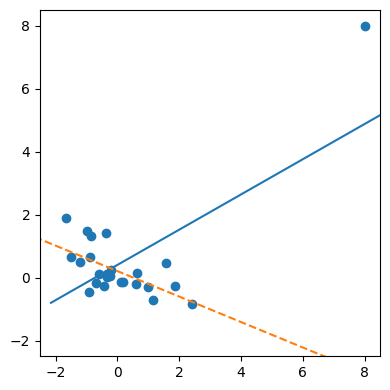

In [63]:
%matplotlib inline
from scipy.stats import linregress

np.random.seed(5)
x = np.random.normal(size=25)
y = -x / 5 + np.random.normal(size=25)
x[0] = 8
y[0] = 8

def abline(slope, intercept, ax):
    """Calculate coordinates of a line based on slope and intercept"""
    x_vals = np.array(ax.get_xlim())
    return (x_vals, intercept + slope * x_vals)

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(x, y)
slope, intercept, _, _, _ = linregress(x, y)
ax.plot(*abline(slope, intercept, ax))
slope, intercept, _, _, _ = linregress(x[1:], y[1:])
ax.plot(*abline(slope, intercept, ax), '--')
ax.set_xlim(-2.5, 8.5)
ax.set_ylim(-2.5, 8.5)

plt.tight_layout()
plt.show()

The package _statsmodel_ provides a number of plots to analyze the data point influence

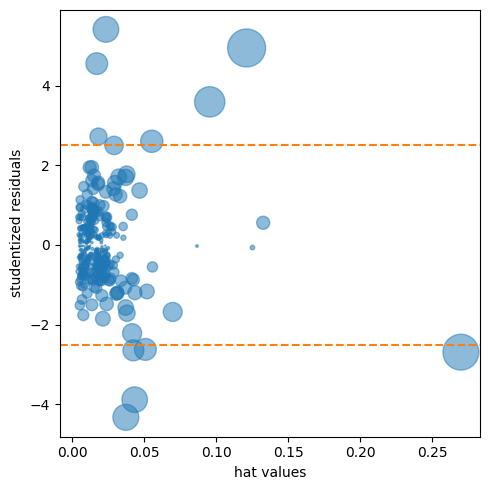

In [64]:
influence = OLSInfluence(result_98105)
fig, ax = plt.subplots(figsize=(5, 5))
ax.axhline(-2.5, linestyle='--', color='C1')
ax.axhline(2.5, linestyle='--', color='C1')
ax.scatter(influence.hat_matrix_diag, influence.resid_studentized_internal, 
           s=1000 * np.sqrt(influence.cooks_distance[0]),
           alpha=0.5)

ax.set_xlabel('hat values')
ax.set_ylabel('studentized residuals')

plt.tight_layout()
plt.show()

In [65]:
mask = [dist < .08 for dist in influence.cooks_distance[0]]
house_infl = house_98105.loc[mask]

ols_infl = sm.OLS(house_infl[outcome], house_infl[predictors].assign(const=1))
result_infl = ols_infl.fit()

pd.DataFrame({
    'Original': result_98105.params,
    'Influential removed': result_infl.params,
})

,Original,Influential removed
SqFtTotLiving,209.602346,230.052569
SqFtLot,38.933315,33.141600
Bathrooms,2282.264145,-16131.879785
Bedrooms,-26320.268796,-22887.865318
BldgGrade,130000.099737,114870.559737
const,-772549.862447,-647137.096716


### R

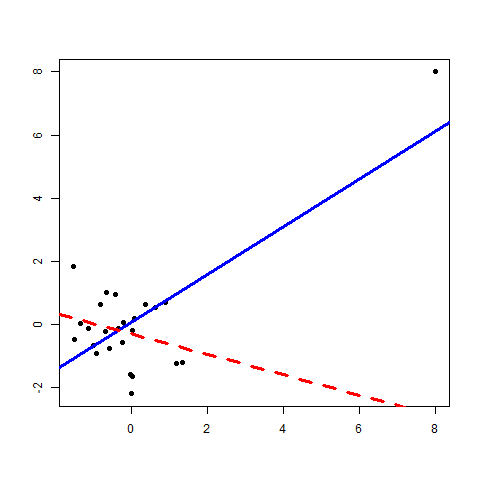

In [66]:
%%R
seed <- 11
set.seed(seed)
x <- rnorm(25)
y <- -x/5 + rnorm(25)
x[1] <- 8
y[1] <- 8

plot(x, y, xlab='', ylab='', pch=16)
model <- lm(y~x)
abline(a=model$coefficients[1], b=model$coefficients[2], col="blue", lwd=3)
model <- lm(y[-1]~x[-1])
abline(a=model$coefficients[1], b=model$coefficients[2], col="red", lwd=3, lty=2)

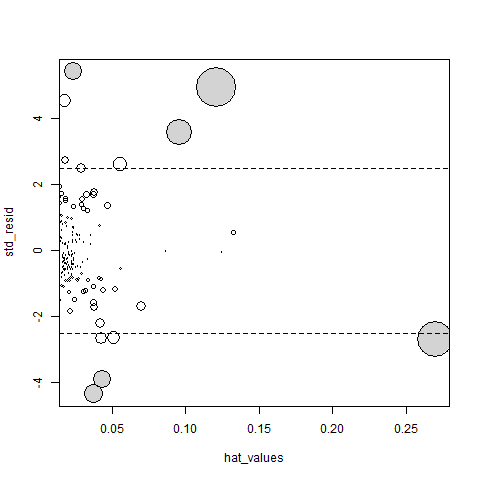

In [67]:
%%R
# influential observations
std_resid <- rstandard(lm_98105)
cooks_D <- cooks.distance(lm_98105)
hat_values <- hatvalues(lm_98105)
plot(subset(hat_values, cooks_D > 0.08), subset(std_resid, cooks_D > 0.08), 
     xlab='hat_values', ylab='std_resid',
     cex=10*sqrt(subset(cooks_D, cooks_D > 0.08)), pch=16, col='lightgrey')
points(hat_values, std_resid, cex=10*sqrt(cooks_D))
abline(h=c(-2.5, 2.5), lty=2)

In [68]:
%%R
lm_98105_inf <- lm(AdjSalePrice ~ SqFtTotLiving + SqFtLot + 
                     Bathrooms +  Bedrooms + BldgGrade,
                   subset=cooks_D<.08, data=house_98105)

## Heteroskedasticity, Non-Normality and Correlated Errors

In [69]:
### Python

The `regplot` in _seaborn_ allows adding a lowess smoothing line to the scatterplot.

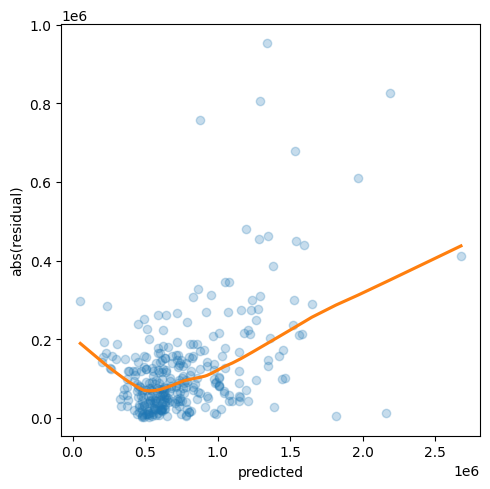

In [70]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.regplot(x=result_98105.fittedvalues, y=np.abs(result_98105.resid), 
            scatter_kws={'alpha': 0.25},
            line_kws={'color': 'C1'},
            lowess=True, ax=ax)
ax.set_xlabel('predicted')
ax.set_ylabel('abs(residual)')

plt.tight_layout()
plt.show()

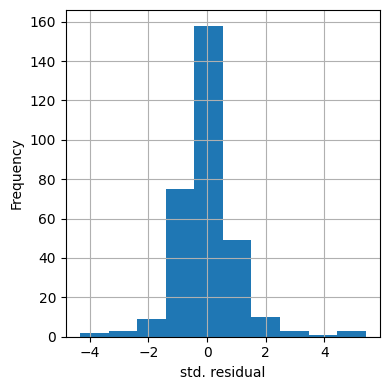

In [71]:
fig, ax = plt.subplots(figsize=(4, 4))
pd.Series(influence.resid_studentized_internal).hist(ax=ax)
ax.set_xlabel('std. residual')
ax.set_ylabel('Frequency')


plt.tight_layout()
plt.show()

### R

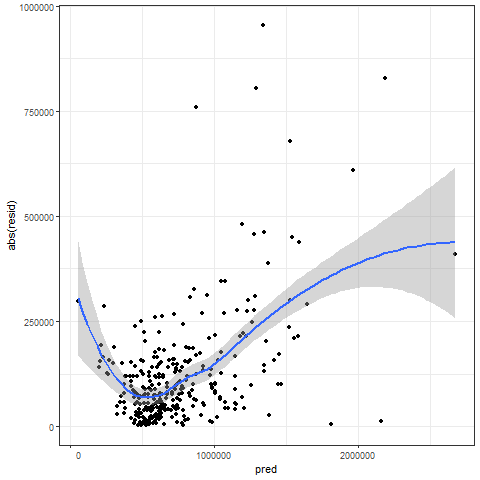

In [72]:
%%R
df <- data.frame(
  resid = residuals(lm_98105),
  pred = predict(lm_98105))

graph <- ggplot(df, aes(pred, abs(resid))) +
  geom_point() +
  geom_smooth(formula=y~x, method='loess') +
  scale_x_continuous(labels = function(x) format(x, scientific = FALSE)) +
  theme_bw()
graph

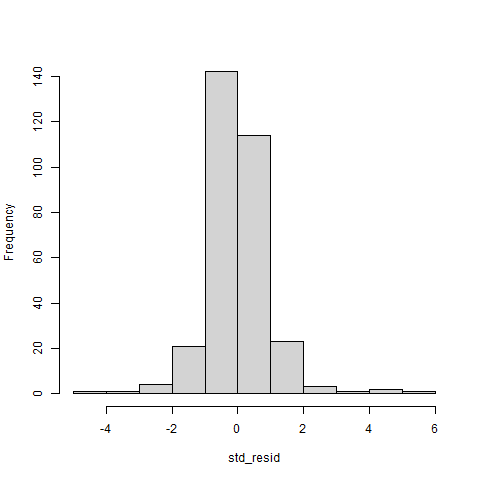

In [73]:
%%R
hist(std_resid, main='')

## Partial Residual Plots and Nonlinearity

### Python

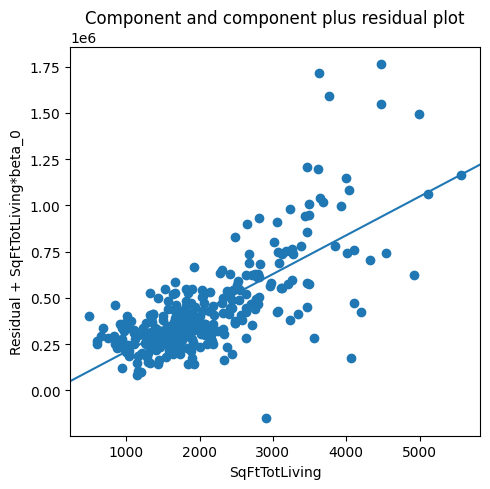

In [74]:
fig, ax = plt.subplots(figsize=(5, 5))
fig = sm.graphics.plot_ccpr(result_98105, 'SqFtTotLiving', ax=ax)

plt.tight_layout()
plt.show()

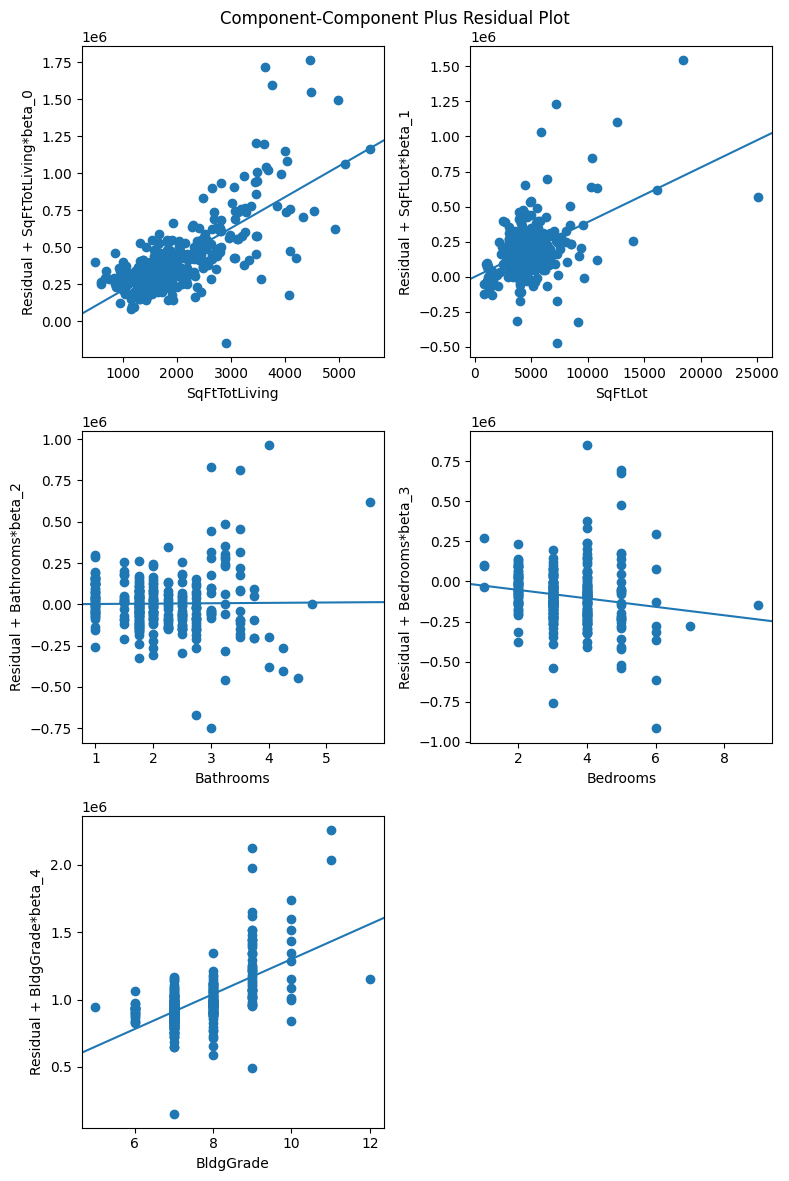

In [75]:
fig = plt.figure(figsize=(8, 12))
fig = sm.graphics.plot_ccpr_grid(result_98105, fig=fig)

### R

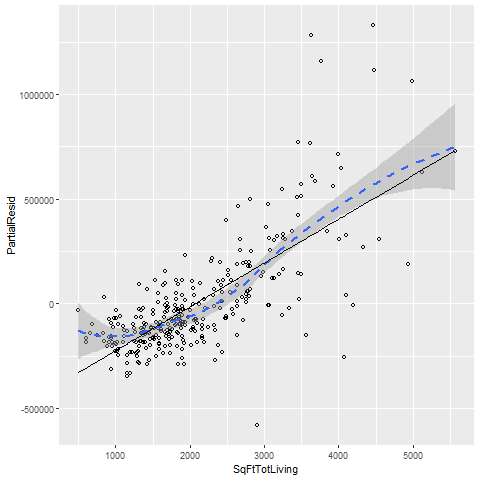

In [76]:
%%R
terms <- predict(lm_98105, type='terms')
partial_resid <- resid(lm_98105) + terms

df <- data.frame(SqFtTotLiving = house_98105[, 'SqFtTotLiving'],
                 Terms = terms[, 'SqFtTotLiving'],
                 PartialResid = partial_resid[, 'SqFtTotLiving'])
graph <- ggplot(df, aes(SqFtTotLiving, PartialResid)) +
  geom_point(shape=1) + scale_shape(solid = FALSE) +
  geom_smooth(linetype=2, formula=y~x, method='loess') + 
  geom_line(aes(SqFtTotLiving, Terms)) + 
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE))
graph

## Polynomial and Spline Regression

### Python

In [77]:
model_poly = smf.ols(formula='AdjSalePrice ~  SqFtTotLiving + np.power(SqFtTotLiving, 2) + ' + 
                'SqFtLot + Bathrooms + Bedrooms + BldgGrade', data=house_98105)
result_poly = model_poly.fit()
print(result_poly.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     211.6
Date:                Wed, 26 Nov 2025   Prob (F-statistic):          9.95e-106
Time:                        19:02:05   Log-Likelihood:                -4217.9
No. Observations:                 313   AIC:                             8450.
Df Residuals:                     306   BIC:                             8476.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

The statsmodels implementation of a partial residual plot works only for linear term. Here is an implementation of a partial residual plot that, while inefficient, works for the polynomial regression.

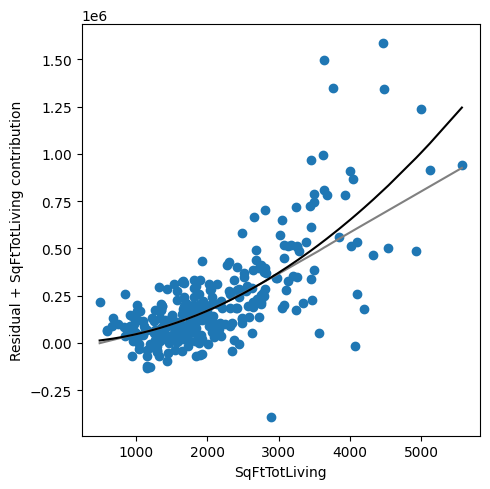

0.03879128168231146


In [78]:
def partialResidualPlot(model, df, outcome, feature, ax):
    y_pred = model.predict(df)
    # determine columns required for model
    required = set(model.params.index).intersection(df.columns)
    required.add(feature)
    copy_df = df[list(required)].copy().astype('float')
    for c in copy_df.columns:
        if c == feature:
            continue
        copy_df.loc[:, c] = 0.0
    feature_prediction = model.predict(copy_df)
    results = pd.DataFrame({
        'feature': df[feature],
        'residual': df[outcome] - y_pred,
        'ypartial': feature_prediction - model.params.iloc[0],
    })
    results = results.sort_values(by=['feature'])
    smoothed = sm.nonparametric.lowess(results.ypartial, results.feature, frac=1/3)
    
    ax.scatter(results.feature, results.ypartial + results.residual)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='gray')
    ax.plot(results.feature, results.ypartial, color='black')
    ax.set_xlabel(feature)
    ax.set_ylabel(f'Residual + {feature} contribution')
    return ax

fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(result_poly, house_98105, 'AdjSalePrice', 'SqFtTotLiving', ax)

plt.tight_layout()
plt.show()
print(result_poly.params.iloc[2])

### R

In [79]:
%%R
lm_poly <- lm(AdjSalePrice ~  poly(SqFtTotLiving, 2) + SqFtLot + 
                BldgGrade +  Bathrooms +  Bedrooms,
              data=house_98105)
terms <- predict(lm_poly, type='terms')
partial_resid <- resid(lm_poly) + terms
lm_poly


Call:
lm(formula = AdjSalePrice ~ poly(SqFtTotLiving, 2) + SqFtLot + 
    BldgGrade + Bathrooms + Bedrooms, data = house_98105)

Coefficients:
            (Intercept)  poly(SqFtTotLiving, 2)1  poly(SqFtTotLiving, 2)2  
             -402530.47               3271519.49                776934.02  
                SqFtLot                BldgGrade                Bathrooms  
                  32.56                135717.06                 -1435.12  
               Bedrooms  
               -9191.94  



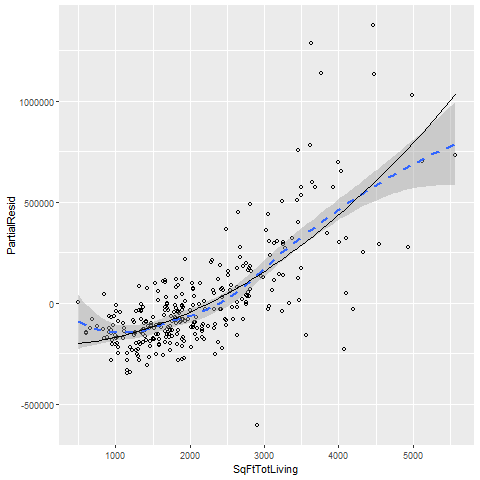

In [80]:
%%R
df <- data.frame(SqFtTotLiving = house_98105[, 'SqFtTotLiving'],
                 Terms = terms[, 1],
                 PartialResid = partial_resid[, 1])
graph <- ggplot(df, aes(SqFtTotLiving, PartialResid)) +
  geom_point(shape=1) + scale_shape(solid = FALSE) +
  geom_smooth(linetype=2, formula=y~x, method='loess') + 
  geom_line(aes(SqFtTotLiving, Terms)) +
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE))
graph

## Splines

### Python

In [81]:
formula = ('AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + ' + 
           'SqFtLot + Bathrooms + Bedrooms + BldgGrade')
model_spline = smf.ols(formula=formula, data=house_98105)
result_spline = model_spline.fit()
print(result_spline.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     131.8
Date:                Wed, 26 Nov 2025   Prob (F-statistic):          7.10e-104
Time:                        19:02:05   Log-Likelihood:                -4211.4
No. Observations:                 313   AIC:                             8445.
Df Residuals:                     302   BIC:                             8486.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


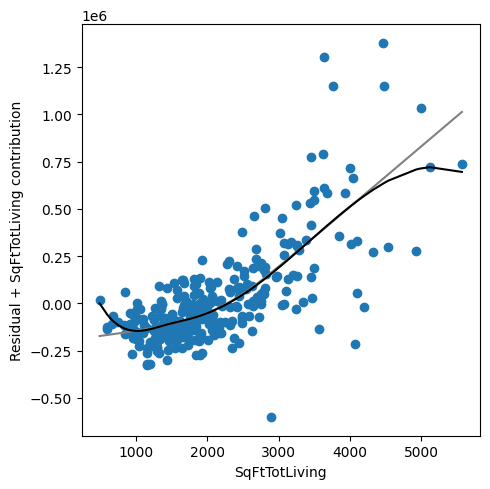

In [82]:
fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(result_spline, house_98105, 'AdjSalePrice', 'SqFtTotLiving', ax)

plt.tight_layout()
plt.show()

### R

In [83]:
%%R
knots <- quantile(house_98105$SqFtTotLiving, p=c(.25, .5, .75))
lm_spline <- lm(AdjSalePrice ~ bs(SqFtTotLiving, knots=knots, degree=3) +  SqFtLot +  
                  Bathrooms + Bedrooms + BldgGrade,  data=house_98105)
lm_spline

terms1 <- predict(lm_spline, type='terms')
partial_resid1 <- resid(lm_spline) + terms1

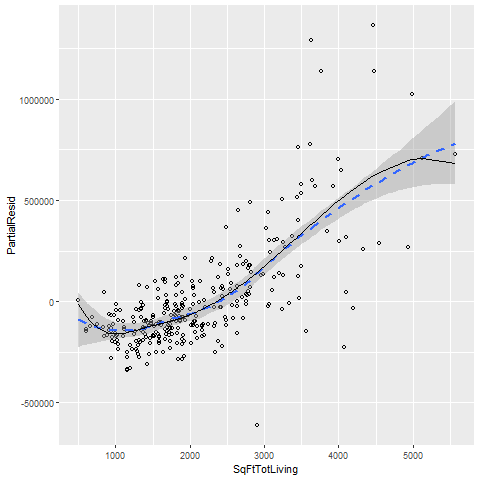

In [84]:
%%R
df1 <- data.frame(SqFtTotLiving = house_98105[, 'SqFtTotLiving'],
                 Terms = terms1[, 1],
                 PartialResid = partial_resid1[, 1])

graph <- ggplot(df1, aes(SqFtTotLiving, PartialResid)) +
  geom_point(shape=1) + scale_shape(solid = FALSE) +
  geom_smooth(linetype=2, formula=y~x, method='loess') + 
  geom_line(aes(SqFtTotLiving, Terms)) +
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE))
graph

## Generalized Additive Models

### Python

#### Using statsmodels

In [85]:
from statsmodels.gam.api import GLMGam, BSplines

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

x_spline = house_98105[predictors]
bs = BSplines(x_spline, df=[10] + [3] * 4, degree=[3] + [2] * 4)
# penalization weight
alpha = np.array([0] * 5)

formula = ('AdjSalePrice ~ SqFtTotLiving + ' + 
           'SqFtLot + Bathrooms + Bedrooms + BldgGrade')

gam_sm = GLMGam.from_formula(formula, data=house_98105, smoother=bs, alpha=alpha)
res_sm = gam_sm.fit()
print(res_sm.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           AdjSalePrice   No. Observations:                  313
Model:                         GLMGam   Df Residuals:                   295.00
Model Family:                Gaussian   Df Model:                        17.00
Link Function:               Identity   Scale:                      2.7471e+10
Method:                         PIRLS   Log-Likelihood:                -4196.6
Date:                Wed, 26 Nov 2025   Deviance:                   8.1039e+12
Time:                        19:02:05   Pearson chi2:                 8.10e+12
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9901
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -3.481e+05   1.18e+05  

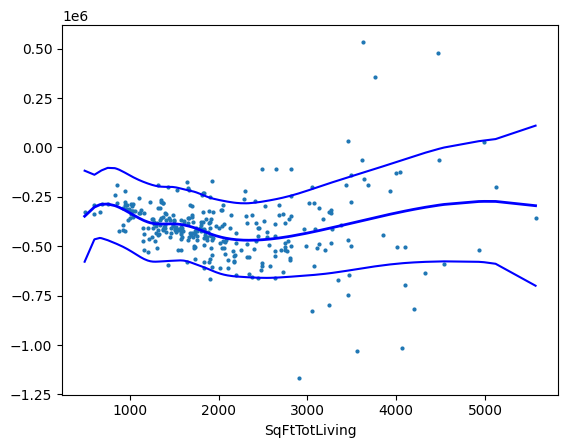

In [86]:
res_sm.plot_partial(0, cpr=True);

#### Using pyGAM

In [87]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'
X = house_98105[predictors].values
y = house_98105[outcome]

## model
gam = LinearGAM(s(0, n_splines=12) + l(1) + l(2) + l(3) + l(4))
gam.gridsearch(X, y)
print(gam.summary())

100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      7.6772
Link Function:                     IdentityLink Log Likelihood:                                 -7833.1159
Number of Samples:                          313 AIC:                                            15683.5863
                                                AICc:                                             15684.14
                                                GCV:                                      30838885095.1677
                                                Scale:                                    29480381715.8292
                                                Pseudo R-Squared:                                   0.8117
Feature Function                  Lam

C:\Users\micha\AppData\Local\Temp\ipykernel_6812\661170992.py:10: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


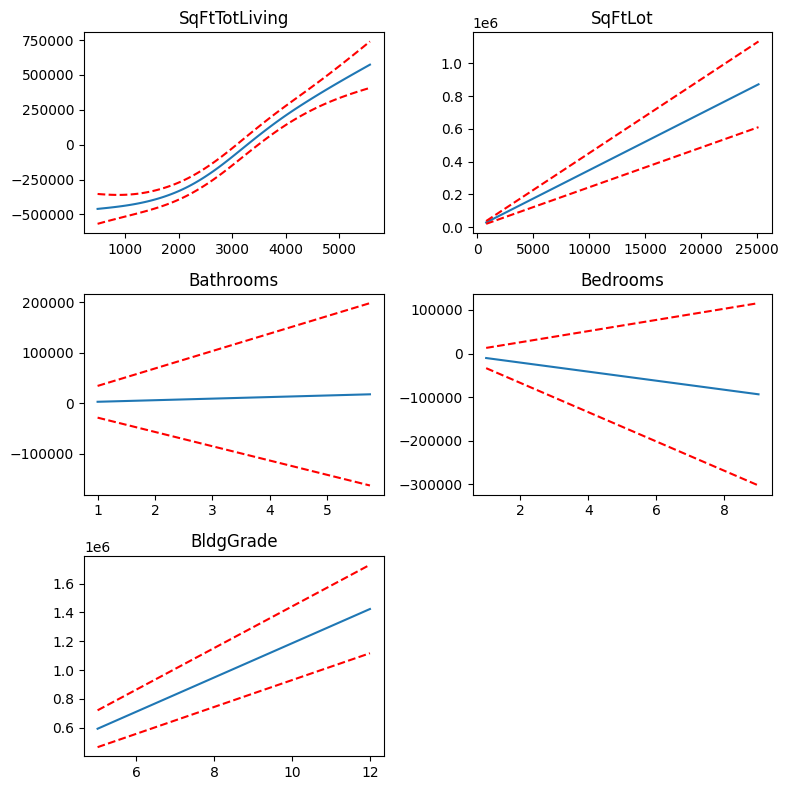

In [88]:
fig, axes = plt.subplots(figsize=(8, 8), ncols=2, nrows=3)

titles = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
for i, title in enumerate(titles):
    ax = axes[i // 2, i % 2]
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], c='r', ls='--')
    ax.set_title(titles[i]);
    
axes[2][1].set_visible(False)

plt.tight_layout()
plt.show()

### R

In [89]:
%%R
lm_gam <- gam(AdjSalePrice ~ s(SqFtTotLiving) + SqFtLot + 
              Bathrooms +  Bedrooms + BldgGrade, 
              data=house_98105)
terms <- predict.gam(lm_gam, type='terms')
partial_resid <- resid(lm_gam) + terms
lm_gam


 gaussian 
Link function: identity 

Formula:
AdjSalePrice ~ s(SqFtTotLiving) + SqFtLot + Bathrooms + Bedrooms + 
    BldgGrade

Estimated degrees of freedom:
4.49  total = 9.49 

GCV score: 30148051324     


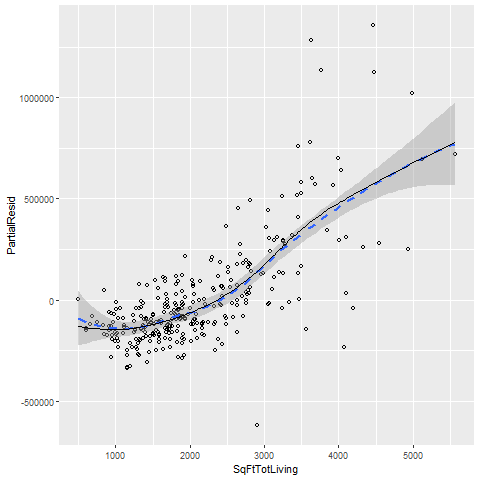

In [90]:
%%R
df <- data.frame(SqFtTotLiving = house_98105[, 'SqFtTotLiving'],
                 Terms = terms[, 5],
                 PartialResid = partial_resid[, 5])
graph <- ggplot(df, aes(SqFtTotLiving, PartialResid)) +
  geom_point(shape=1) + scale_shape(solid = FALSE) +
  geom_smooth(linetype=2, formula=y~x, method='loess') + 
  geom_line(aes(SqFtTotLiving, Terms)) +
  scale_y_continuous(labels = function(x) format(x, scientific = FALSE))
graph

# Additional material - not in book
# Regularization
## Lasso

In [91]:
from sklearn.linear_model import Lasso, LassoLars, LassoCV, LassoLarsCV
from sklearn.preprocessing import StandardScaler

In [92]:
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
          'Bedrooms', 'BldgGrade']

house = pd.read_csv(HOUSE_CSV, sep='\t')
print(house[subset].head())

   AdjSalePrice  SqFtTotLiving  SqFtLot  Bathrooms  Bedrooms  BldgGrade
1      300805.0           2400     9373       3.00         6          7
2     1076162.0           3764    20156       3.75         4         10
3      761805.0           2060    26036       1.75         4          8
4      442065.0           3200     8618       3.75         5          7
5      297065.0           1720     8620       1.75         4          7


In [93]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'NbrLivingUnits',
              'SqFtFinBasement', 'YrBuilt', 'YrRenovated', 
              'NewConstruction']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True)
X['NewConstruction'] = [1 if nc else 0 for nc in X['NewConstruction']]
columns = X.columns
# X = StandardScaler().fit_transform(X * 1.0)
y = house[outcome]

house_lm = LinearRegression()
print(house_lm.fit(X, y))

LinearRegression()


In [94]:
house_lasso = Lasso(alpha=10)
print(house_lasso.fit(X, y))

Lasso(alpha=10)


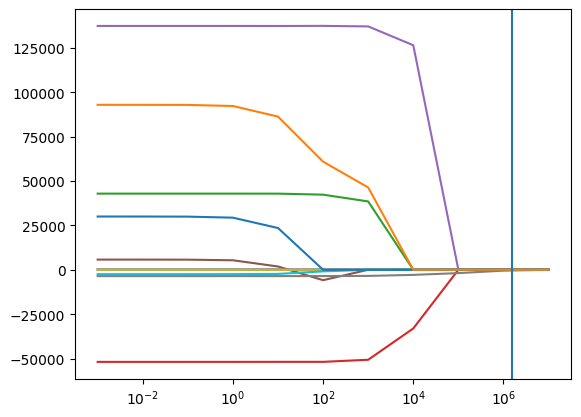

In [95]:
Method = LassoLars
MethodCV = LassoLarsCV
Method = Lasso
MethodCV = LassoCV

alpha_values = []
results = []
for alpha in [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000]:
    model = Method(alpha=alpha)
    model.fit(X, y)
    alpha_values.append(alpha)
    results.append(model.coef_)
modelCV = MethodCV(cv=5)
modelCV.fit(X, y)
ax = pd.DataFrame(results, index=alpha_values, columns=columns).plot(logx=True, legend=False)
ax.axvline(modelCV.alpha_)
plt.show()

In [96]:
pd.DataFrame({
    'name': columns,
    'coef': modelCV.coef_, 
})

,name,coef
0,SqFtTotLiving,289.048846
1,SqFtLot,0.029471
2,Bathrooms,0.000000
3,Bedrooms,-0.000000
4,BldgGrade,0.000000
5,NbrLivingUnits,-0.000000
6,SqFtFinBasement,3.316479
7,YrBuilt,-0.000000
8,YrRenovated,45.727472
9,NewConstruction,-0.000000


In [97]:
# Intercept: 6177658.144
# Coefficients:
#  SqFtTotLiving: 199.27474217544048
#  BldgGrade: 137181.13724627026
#  YrBuilt: -3564.934870415041
#  Bedrooms: -51974.76845567939
#  Bathrooms: 42403.059999677665
#  PropertyType_Townhouse: 84378.9333363999
#  SqFtFinBasement: 7.032178917565108
#  PropertyType_Single Family: 22854.87954019308